
--- Visualizing Geographical Data ---
Geographical features: Latitude, Longitude


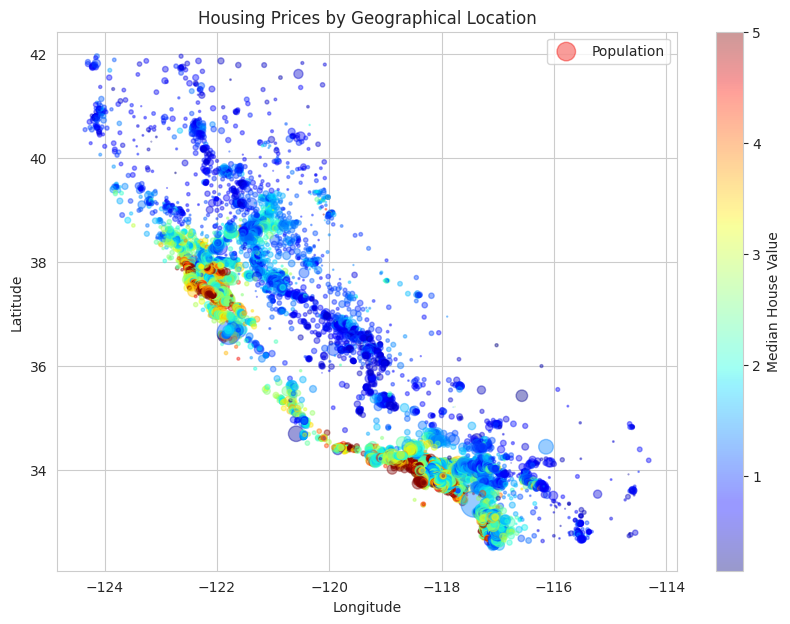


--- Analysis of Geographical Data with Housing Prices ---
The graph indicates that:
1. Areas with higher housing prices (indicated by warmer colors like red/orange) are generally concentrated along the coastlines, especially in the major metropolitan areas of California.
2. Conversely, inland areas and regions further north tend to have lower housing prices (indicated by cooler colors like blue/green).
3. The size of the circles, representing population, suggests that densely populated areas often correspond to higher housing values, although there are exceptions.
This visualization helps in identifying geographical patterns and hotspots of housing values, which is crucial for understanding the market and for feature engineering (e.g., creating distance-to-coast features).


In [9]:
import matplotlib.pyplot as plt

# 4. Visualize Geographical Data with Housing Prices
print("\n--- Visualizing Geographical Data ---")

# Geographical features are 'Latitude' and 'Longitude'
print("Geographical features: Latitude, Longitude")

# Plotting the geographical data, colored by housing price
plt.figure(figsize=(10, 7))
scatter_plot = plt.scatter(df['Longitude'], df['Latitude'], alpha=0.4,
            s=df['Population']/100, label='Population',
            c=df['MedHouseVal'], cmap=plt.get_cmap('jet'))
plt.colorbar(scatter_plot, label='Median House Value') # Add colorbar explicitly
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Housing Prices by Geographical Location')
plt.legend()
plt.show()

print("\n--- Analysis of Geographical Data with Housing Prices ---")
print("The graph indicates that:")
print("1. Areas with higher housing prices (indicated by warmer colors like red/orange) are generally concentrated along the coastlines, especially in the major metropolitan areas of California.")
print("2. Conversely, inland areas and regions further north tend to have lower housing prices (indicated by cooler colors like blue/green).")
print("3. The size of the circles, representing population, suggests that densely populated areas often correspond to higher housing values, although there are exceptions.")
print("This visualization helps in identifying geographical patterns and hotspots of housing values, which is crucial for understanding the market and for feature engineering (e.g., creating distance-to-coast features).")

In [7]:
from sklearn.model_selection import train_test_split
import numpy as np

# 3. Demonstrate the process of creating a test set
print("\n--- Creating Test Sets ---")

# --- Stratified Test Set Setup ---
# First, create income categories (strata) based on 'MedInc' in the main DataFrame.
# This needs to be done BEFORE any splits, so all derived sets can inherit it.
# Divide by 1.5 to limit the number of income categories
# and cap at 5 to have at most 5 categories.
df["income_cat"] = np.ceil(df["MedInc"] / 1.5)
df["income_cat"] = df["income_cat"].where(df["income_cat"] < 5, 5.0)

# --- Random Test Set ---
# A simple random split shuffles the entire dataset and then splits it into training and test sets.
# Each instance has an equal chance of being selected for the test set.

# In this example, 20% of the data will be used for the test set.
# random_state is set for reproducibility.
print("\nCreating a random test set (20% of the data)...")

train_set_random, test_set_random = train_test_split(df, test_size=0.2, random_state=42)

print(f"Random Test Set Size: {len(test_set_random)} samples")
print(f"Random Training Set Size: {len(train_set_random)} samples")


# --- Stratified Test Set ---
# Stratified sampling ensures that the test set is representative of the population for a specific feature.
# This is important when a feature has a skewed distribution, as purely random sampling might result in a test set
# that doesn't adequately represent all categories of that feature.

# For the California Housing dataset, 'MedInc' (Median Income) is an important feature, and we might want to ensure
# that the test set has a similar proportion of different income categories as the full dataset.

print("\nCreating a stratified test set based on 'MedInc' categories (20% of the data)...")

strat_train_set, strat_test_set = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["income_cat"])

print(f"Stratified Test Set Size: {len(strat_test_set)} samples")
print(f"Stratified Training Set Size: {len(strat_train_set)} samples")

# Verify the proportions in the full dataset, random test set, and stratified test set
print("\nIncome Category Proportions:")
print("Full Dataset:\n", df["income_cat"].value_counts() / len(df))
print("\nRandom Test Set:\n", test_set_random["income_cat"].value_counts() / len(test_set_random))
print("\nStratified Test Set:\n", strat_test_set["income_cat"].value_counts() / len(strat_test_set))

# Drop the 'income_cat' column from the main dataframe and all split sets after use
for set_ in (df, train_set_random, test_set_random, strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

print("\n'income_cat' column dropped from datasets.")


--- Creating Test Sets ---

Creating a random test set (20% of the data)...
Random Test Set Size: 4128 samples
Random Training Set Size: 16512 samples

Creating a stratified test set based on 'MedInc' categories (20% of the data)...
Stratified Test Set Size: 4128 samples
Stratified Training Set Size: 16512 samples

Income Category Proportions:
Full Dataset:
 income_cat
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: count, dtype: float64

Random Test Set:
 income_cat
3.0    0.358527
2.0    0.324370
4.0    0.167393
5.0    0.109496
1.0    0.040213
Name: count, dtype: float64

Stratified Test Set:
 income_cat
3.0    0.350533
2.0    0.318798
4.0    0.176357
5.0    0.114341
1.0    0.039971
Name: count, dtype: float64

'income_cat' column dropped from datasets.


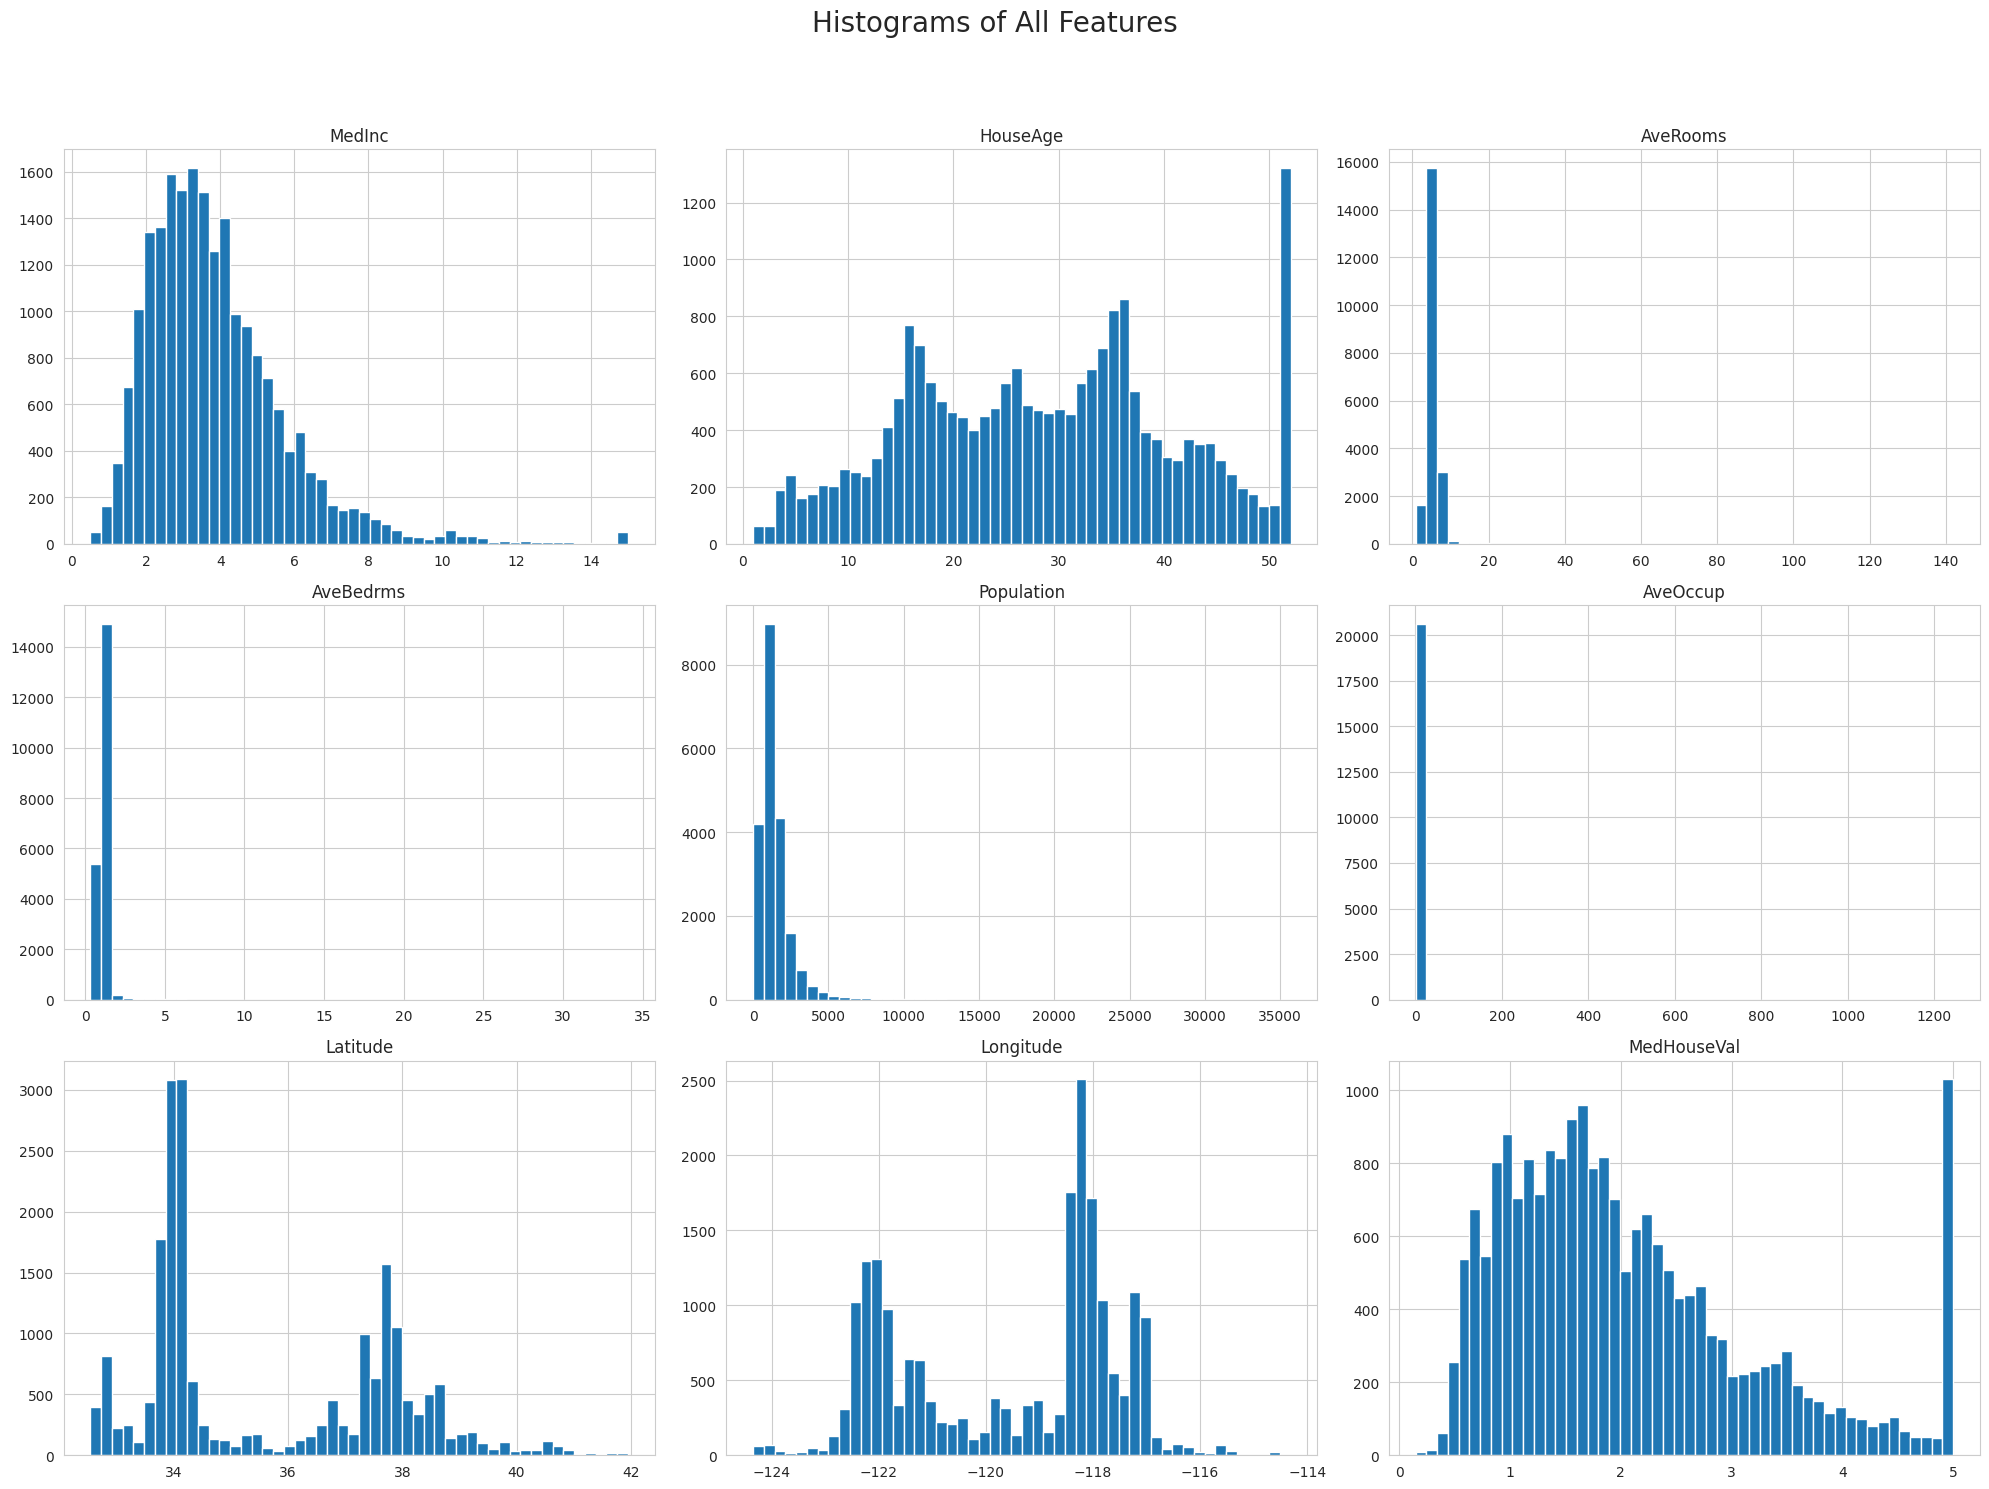

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Plot histogram for each numerical feature
df.hist(bins=50, figsize=(20, 15))
plt.suptitle("Histograms of All Features", y=1.02, fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Histogram Analysis for `MedInc` and `HouseAge`

Let's analyze the histograms, specifically focusing on `MedInc` (Median Income) and `HouseAge` (Median House Age):

**Median Income (`MedInc`)**: The histogram for `MedInc` is right-skewed, meaning the distribution has a long tail on the right. This indicates that most districts have lower to medium median incomes, with fewer districts having very high median incomes. The values are capped at around 15.0001, which is a common practice in datasets to prevent extremely high outliers from dominating the analysis.

**House Age (`HouseAge`)**: The histogram for `HouseAge` shows a distribution where older houses (around 52 years) are more numerous, suggesting a cap or a concentration of very old properties. There's also a noticeable peak for newer homes (around 10-20 years). This feature appears to be somewhat uniformly distributed across ages for younger houses but has a significant spike at the maximum age, indicating that all houses older than a certain threshold (e.g., 52 years) are recorded as 52.

In [6]:
from sklearn.model_selection import train_test_split
import numpy as np

# 3. Demonstrate the process of creating a test set
print("\n--- Creating Test Sets ---")

# --- Stratified Test Set Setup ---
# First, create income categories (strata) based on 'MedInc' in the main DataFrame.
# This needs to be done BEFORE any splits, so all derived sets can inherit it.
# Divide by 1.5 to limit the number of income categories
# and cap at 5 to have at most 5 categories.
df["income_cat"] = np.ceil(df["MedInc"] / 1.5)
df["income_cat"] = df["income_cat"].where(df["income_cat"] < 5, 5.0)

# --- Random Test Set ---
# A simple random split shuffles the entire dataset and then splits it into training and test sets.
# Each instance has an equal chance of being selected for the test set.

# In this example, 20% of the data will be used for the test set.
# random_state is set for reproducibility.
print("\nCreating a random test set (20% of the data)...")

train_set_random, test_set_random = train_test_split(df, test_size=0.2, random_state=42)

print(f"Random Test Set Size: {len(test_set_random)} samples")
print(f"Random Training Set Size: {len(train_set_random)} samples")


# --- Stratified Test Set ---
# Stratified sampling ensures that the test set is representative of the population for a specific feature.
# This is important when a feature has a skewed distribution, as purely random sampling might result in a test set
# that doesn't adequately represent all categories of that feature.

# For the California Housing dataset, 'MedInc' (Median Income) is an important feature, and we might want to ensure
# that the test set has a similar proportion of different income categories as the full dataset.

print("\nCreating a stratified test set based on 'MedInc' categories (20% of the data)...")

strat_train_set, strat_test_set = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["income_cat"])

print(f"Stratified Test Set Size: {len(strat_test_set)} samples")
print(f"Stratified Training Set Size: {len(strat_train_set)} samples")

# Verify the proportions in the full dataset, random test set, and stratified test set
print("\nIncome Category Proportions:")
print("Full Dataset:\n", df["income_cat"].value_counts() / len(df))
print("\nRandom Test Set:\n", test_set_random["income_cat"].value_counts() / len(test_set_random))
print("\nStratified Test Set:\n", strat_test_set["income_cat"].value_counts() / len(strat_test_set))

# Drop the 'income_cat' column from the main dataframe and all split sets after use
for set_ in (df, train_set_random, test_set_random, strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

print("\n'income_cat' column dropped from datasets.")


--- Creating Test Sets ---

Creating a random test set (20% of the data)...
Random Test Set Size: 4128 samples
Random Training Set Size: 16512 samples

Creating a stratified test set based on 'MedInc' categories (20% of the data)...
Stratified Test Set Size: 4128 samples
Stratified Training Set Size: 16512 samples

Income Category Proportions:
Full Dataset:
 income_cat
3.0    0.350581
2.0    0.318847
4.0    0.176308
5.0    0.114438
1.0    0.039826
Name: count, dtype: float64

Random Test Set:
 income_cat
3.0    0.358527
2.0    0.324370
4.0    0.167393
5.0    0.109496
1.0    0.040213
Name: count, dtype: float64

Stratified Test Set:
 income_cat
3.0    0.350533
2.0    0.318798
4.0    0.176357
5.0    0.114341
1.0    0.039971
Name: count, dtype: float64

'income_cat' column dropped from datasets.


### Difference Between Random and Stratified Test Set

**Random Sampling**
*   **How it works**: In purely random sampling, instances are selected entirely by chance from the dataset. Each instance has an equal probability of being chosen for the test set.
*   **Advantages**: Simple to implement and often works well for large datasets where the dataset is relatively homogeneous.
*   **Disadvantages**: If the dataset is not very large or contains features with skewed distributions (i.e., some categories are rare), random sampling might lead to a test set that is not representative of the overall population. This can introduce a *sampling bias*, meaning the test set might not accurately reflect the patterns present in the training data, leading to less reliable model evaluation.

**Stratified Sampling**
*   **How it works**: Stratified sampling divides the dataset into homogeneous subgroups (called 'strata') based on one or more important features. Then, it draws a proportionate number of instances from each stratum to ensure that the test set accurately reflects the proportions of these strata in the overall dataset.
*   **Advantages**: Ensures that the test set is representative of the population with respect to the chosen stratification features. This is crucial when you want to avoid sampling bias and ensure that your model's performance on the test set is a true indicator of its performance on new, unseen data.
*   **Disadvantages**: More complex to implement than random sampling, as it requires identifying relevant features for stratification and creating strata. If not carefully chosen, the stratification features might not be the most important for maintaining representativeness.

In our example, we stratified based on the `MedInc` (Median Income) categories to ensure that different income levels are proportionally represented in both the training and test sets. This helps prevent a scenario where, by chance, the test set might end up with too many high-income districts and too few low-income districts, or vice-versa, which could bias the evaluation of the model.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Dataset loaded successfully. Displaying the first 5 rows:")
display(df.head())

Dataset loaded successfully. Displaying the first 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Now, let's perform the `describe()` and `info()` steps to get a statistical summary and information about the DataFrame, respectively.

In [2]:
# Display descriptive statistics of the DataFrame
print("\nDescriptive statistics of the DataFrame:")
display(df.describe())


Descriptive statistics of the DataFrame:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [3]:
# Display a concise summary of the DataFrame, including data types and non-null values
print("\nInformation about the DataFrame (data types, non-null counts, memory usage):")
df.info()


Information about the DataFrame (data types, non-null counts, memory usage):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
